In [178]:
import numpy as np

In [179]:
import pandas as pd #`for data manipulation and analysis
import numpy as np #`for numerical operations
import matplotlib.pyplot as plt #`for data visualization
import seaborn as sns #`for statistical data visualization
from sklearn.model_selection import train_test_split #`for splitting the dataset into training and testing sets
from sklearn.linear_model import LinearRegression #`for linear regression modeling
from sklearn.metrics import mean_squared_error, r2_score #`for evaluating the performance of the model 


In [180]:
# Loading the dataset 
df = pd.read_csv('C:\\Users\\user\\Desktop\\medical insurance cost predict- project\\data\\medical_insurance.csv')



-> In this section, I will load the dataset and take a first look at its size, structure, and key variables.
This step is important because it helps us understand what kind of data we are working with before applying any models

In [181]:
# checking the first few rows of the dataset
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


## Dataset Shape and Columns
- Here I will check the size of the dataset and list all the available columns.
- This helps to confirm the number of rows and features we are going to use in the analysis.

In [182]:
df.info() #checking the information about the dataset


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [183]:
df.info() #checking the information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [184]:
#checking shape and columns name

print("Shape of the dataset:", df.shape)
print("Columns in the dataset:", df.columns.tolist())

Shape of the dataset: (2772, 7)
Columns in the dataset: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [185]:
# Basic statistics (I will generate basic statistics for the numerical columns in the dataset)
# this help me to understand the distributiion of the numerical variable such as age, BMI and charges 

df.describe()



,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [186]:
# Categorical variable distribution (Checking distribution of categoriable variables like sex, BMI, Children and region)

print("Sex:\n", df['sex'].value_counts(), "\n")
print("Smoker:\n", df['smoker'].value_counts(),"\n")
print("Region:\n", df['region'].value_counts(), "\n")
print("Children:\n", df['children'].value_counts(), "\n")

Sex:
 sex
male      1406
female    1366
Name: count, dtype: int64 

Smoker:
 smoker
no     2208
yes     564
Name: count, dtype: int64 

Region:
 region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64 

Children:
 children
0    1186
1     672
2     496
3     324
4      52
5      42
Name: count, dtype: int64 



In [187]:
# Data Cleaning and Preprocessing
# it will check missing values, potential outliers and encoding, incosistency categorical variables 

#checking missing values 
print("Missing values in such dataset:\n", df.isnull().sum())

Missing values in such dataset:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [188]:
#Checking duplicates 
print("\nDuplicates values in such dataset:\n", df.duplicated().sum())



Duplicates values in such dataset:
 1435


In [189]:
#Quick look data types
print("Data types in the dataset:\n", df.dtypes)

Data types in the dataset:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [190]:
#Remove Duplicates 
# I will remove duplicates row from dataset to ensure data quality and avoid biased results in the analysis and modeling process
df.drop_duplicates(inplace = True)


In [191]:
df.shape

(1337, 7)

In [192]:
# EDA (Exploratory Data Analysis) 
# I will perform EDA to understand the relationships between variables, identify patterns and trends, and gain insights into the data. This will include visualizaion and statistical analysis to explore the distribution of the target variable (charges) and its relationship with other features in the dataset. 
# Goal to check distributiion, correlation and patterns thst mights influence the medical insurance costs


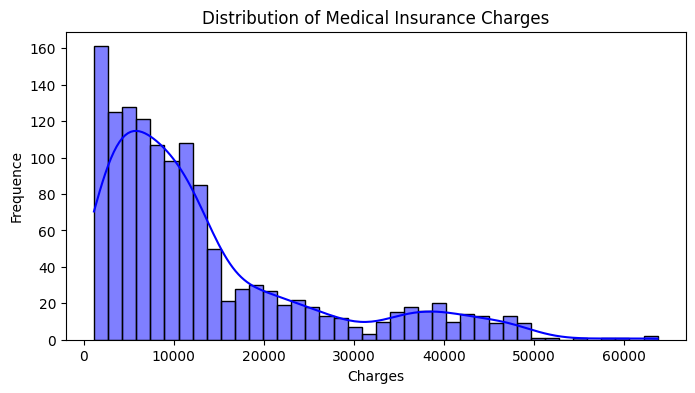

In [193]:
# Distribution of the target variable (Charges) 

#Plot ditrinution of charges 
plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], bins=40, kde=True, color="blue")
plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequence")
plt.show()


#### Distribution of Charges is highly skewed 



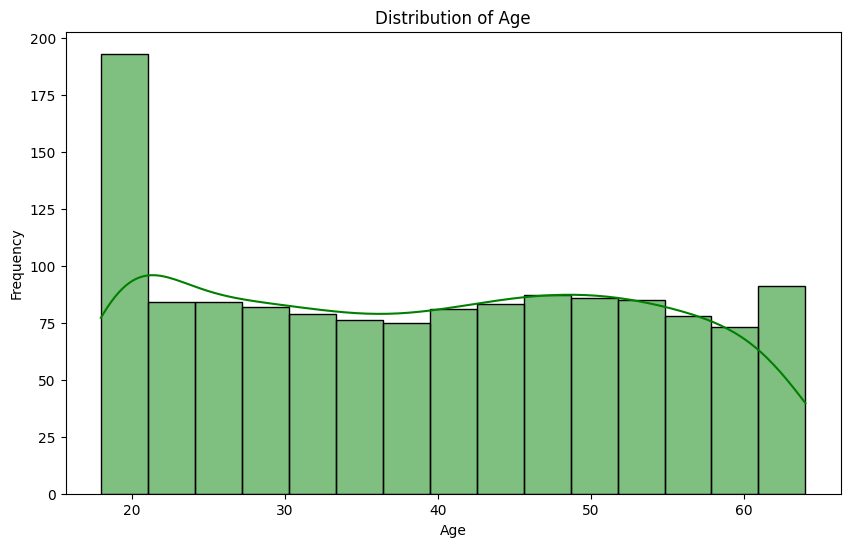

In [194]:
# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(df["age"], bins = 15, kde=True, color="green")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

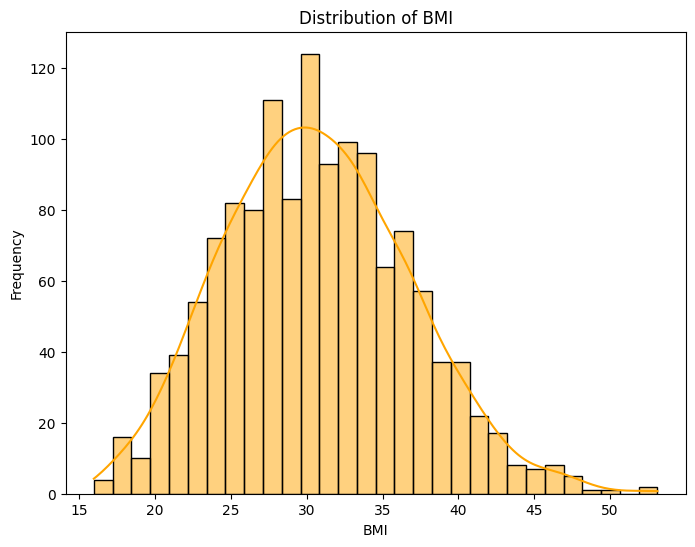

In [195]:
# Distribution of the BMI (This will help to understand the overall health profile of the insured individuals)
plt.figure(figsize=(8, 6))
sns.histplot(df['bmi'], bins= 30, kde=True, color="orange")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

           

C:\Users\user\AppData\Local\Temp\ipykernel_13116\3753563225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='children', data=df, palette= 'pastel')


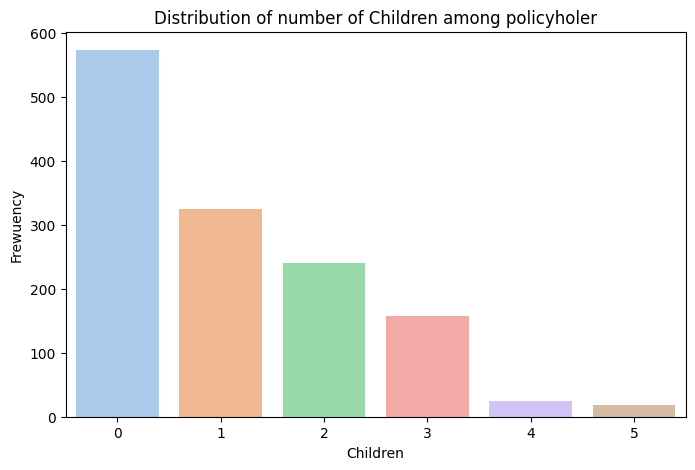

In [196]:
# Distribution of Children 
plt.figure(figsize=(8, 5))
sns.countplot(x='children', data=df, palette= 'pastel')
plt.title("Distribution of number of Children among policyholer")
plt.xlabel("Children")
plt.ylabel("Frewuency")
plt.show()

The distribution of the children variable shows that the majority of policyholders have no children.


C:\Users\user\AppData\Local\Temp\ipykernel_13116\3759926244.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=df, palette= 'Set2')


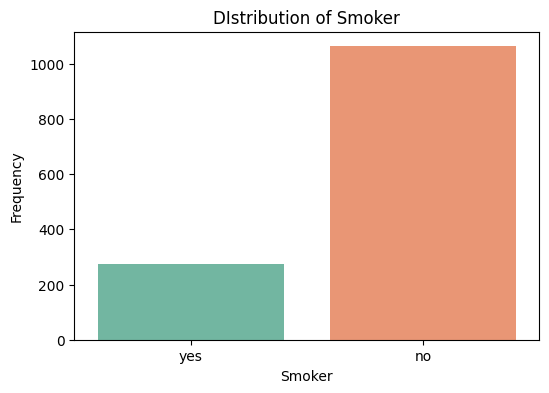

In [197]:
# Distribution of Smoker
plt.figure(figsize=(6, 4))
sns.countplot(x='smoker', data=df, palette= 'Set2')
plt.title("DIstribution of Smoker")
plt.xlabel("Smoker")
plt.ylabel("Frequency")
plt.show()

The majority of policyholders are non-smokers, while smokers represent a smaller portion of the dataset.


C:\Users\user\AppData\Local\Temp\ipykernel_13116\847623167.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='coolwarm')


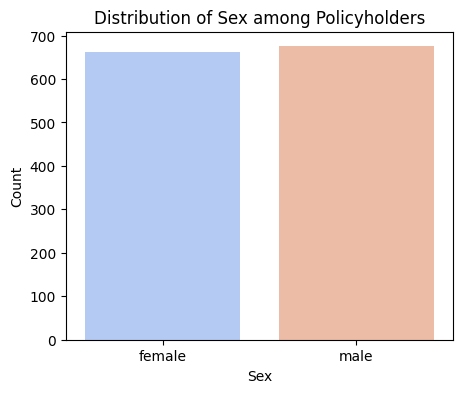

In [198]:
# distribution of sex
plt.figure(figsize=(5,4))
sns.countplot(x='sex', data=df, palette='coolwarm')
plt.title("Distribution of Sex among Policyholders")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

Sex: The dataset is very balanced between male and female policyholders (almost equal). This means there is no gender bias in the dataset.


C:\Users\user\AppData\Local\Temp\ipykernel_13116\448008073.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, palette='muted')


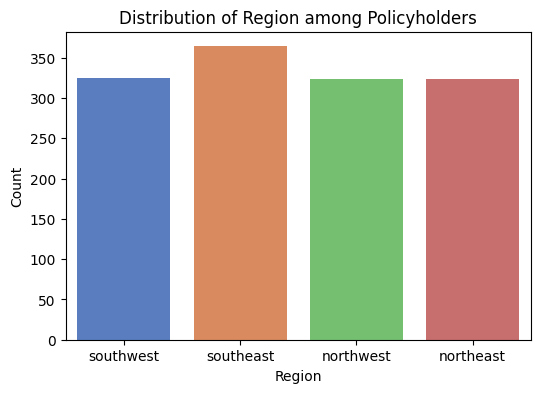

In [199]:
# distribution of region
plt.figure(figsize=(6,4))
sns.countplot(x='region', data=df, palette='muted')
plt.title("Distribution of Region among Policyholders")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

Region: The distribution of policyholders across the four regions (southeast, southwest, northwest, northeast) is also fairly even.


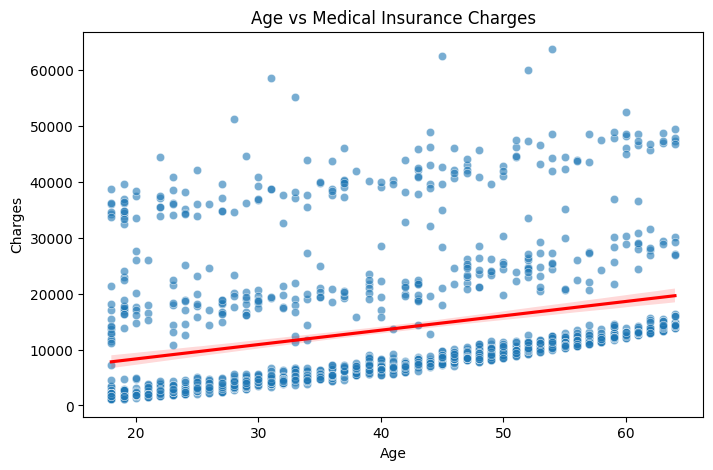

In [200]:
# Age vs Charges (Now I will analyze the relationship between Age and Charges.)
# age vs charges (scatter plot with trendline)
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df, alpha=0.6)
sns.regplot(x='age', y='charges', data=df, scatter=False, color='red')  # trend line
plt.title("Age vs Medical Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

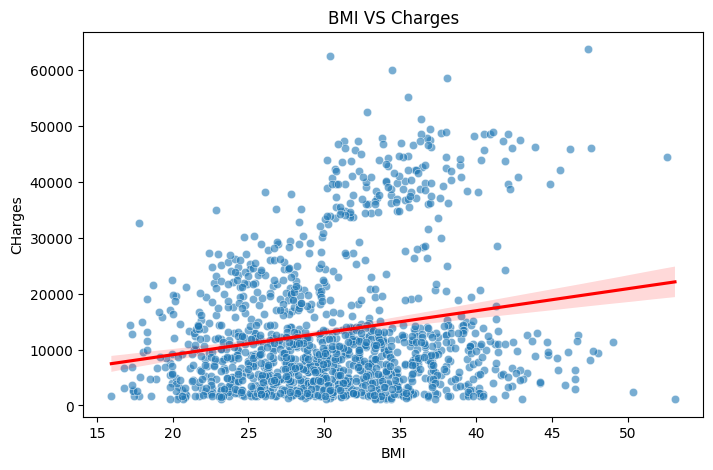

In [201]:
# BMI vs Charges (Analyzing the relationship between BMI and Charges)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='bmi', y='charges', data=df, alpha=0.6,)
sns.regplot(x='bmi', y='charges', data=df, scatter=False, color='red')
plt.title("BMI VS Charges")
plt.xlabel("BMI")
plt.ylabel("CHarges")
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_13116\1686850467.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='children', y='charges', data=df, palette='Set3')


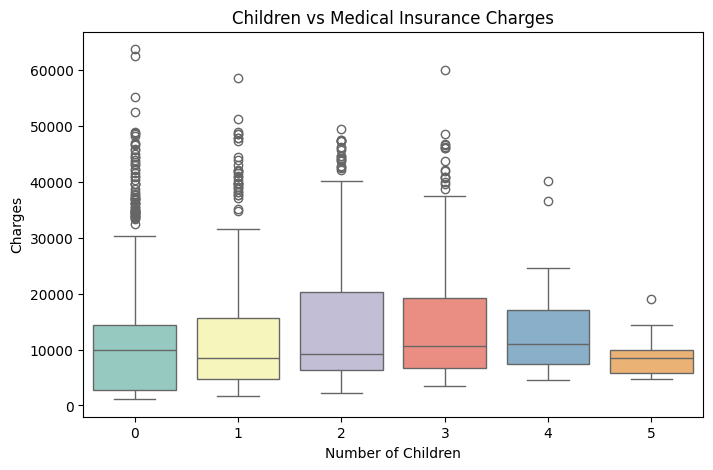

In [202]:
#Childre VS Charges - boxplot (Now I will analyze the relationship between Number of Children and Charges.)

plt.figure(figsize=(8,5))
sns.boxplot(x='children', y='charges', data=df, palette='Set3')
plt.title("Children vs Medical Insurance Charges")
plt.xlabel("Number of Children")
plt.ylabel("Charges")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_13116\3300315802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


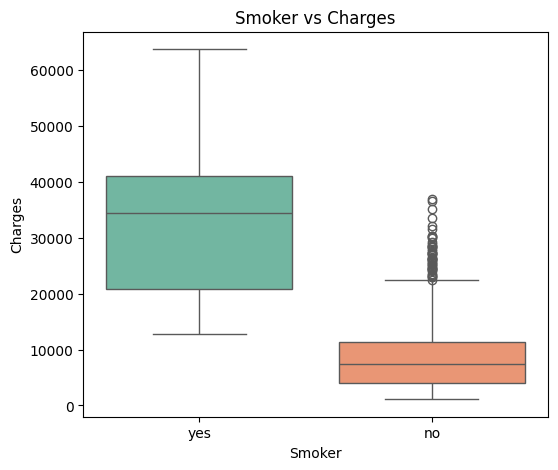

In [203]:
# smoker vs charges (boxplot)
plt.figure(figsize=(6, 5))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title("Smoker vs Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_13116\1245440977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='charges', data=df, palette='coolwarm')


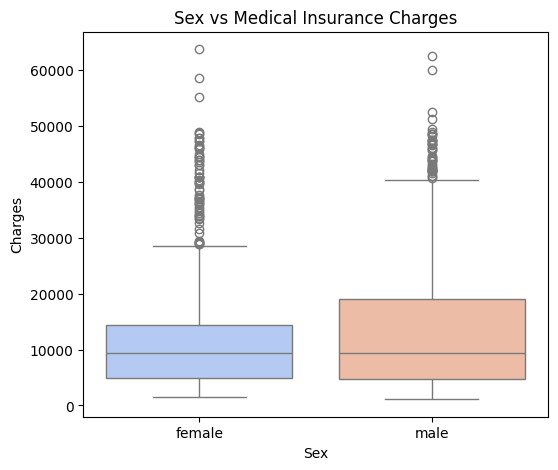

In [204]:
# sex vs charges (boxplot)
plt.figure(figsize=(6,5))
sns.boxplot(x='sex', y='charges', data=df, palette='coolwarm')
plt.title("Sex vs Medical Insurance Charges")
plt.xlabel("Sex")
plt.ylabel("Charges")
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_13116\453230331.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='charges', data=df, palette = 'pastel')


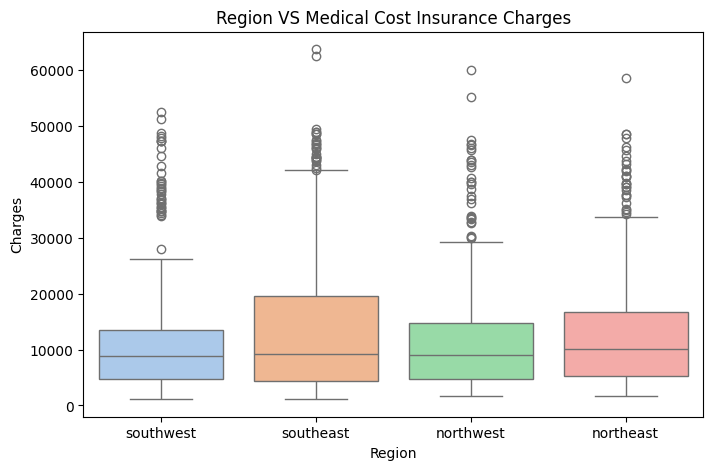

In [205]:
# Region vs Charges
plt.figure(figsize=(8, 5))
sns.boxplot(x='region', y='charges', data=df, palette = 'pastel')
plt.title("Region VS Medical Cost Insurance Charges")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()

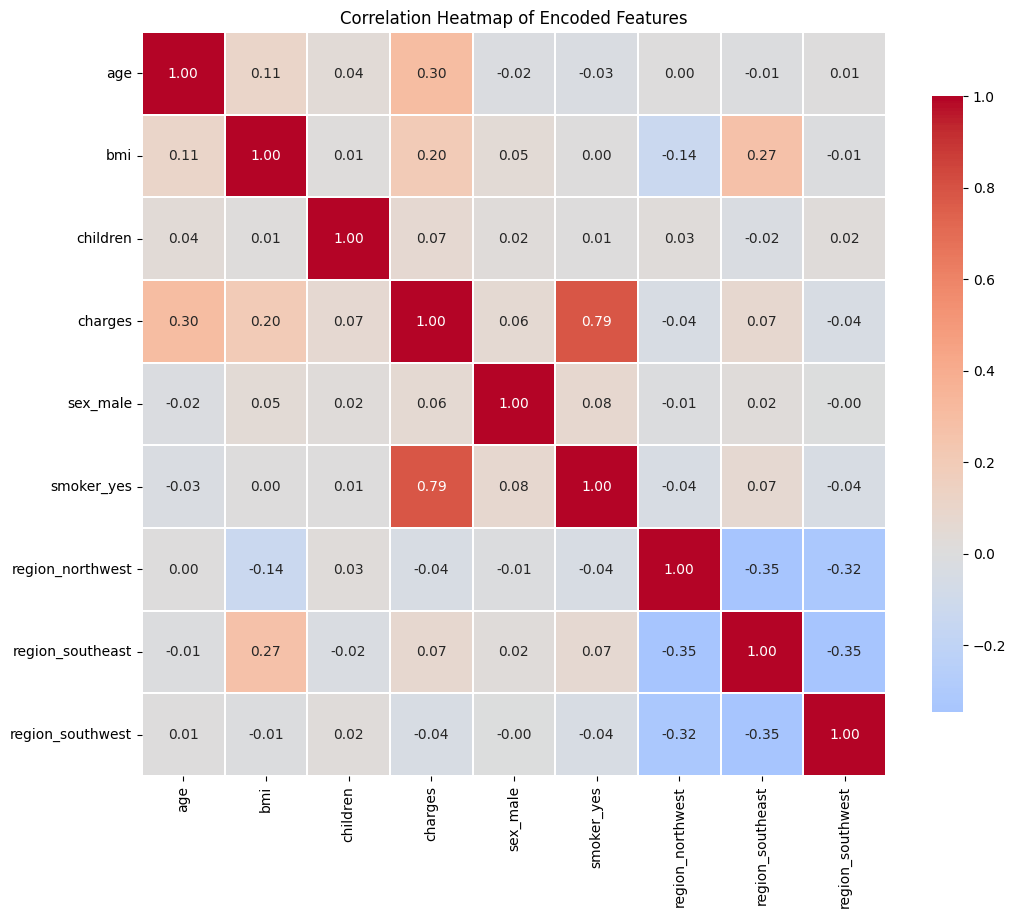

In [206]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Encoded Features")
plt.show()

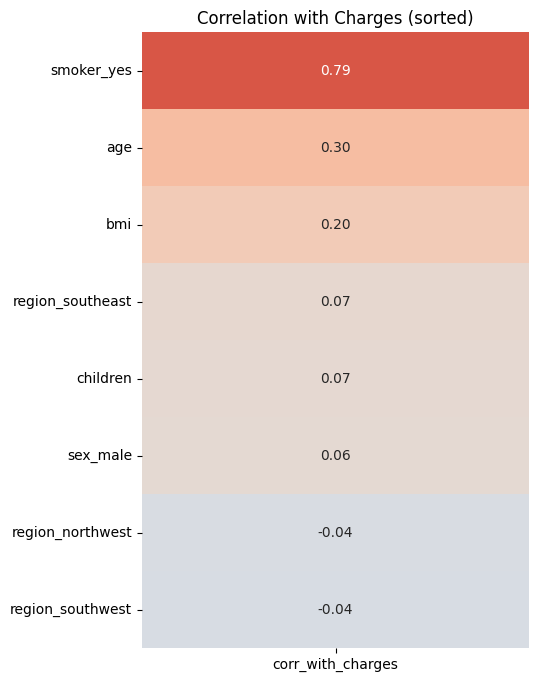

In [207]:
# zoomed view: correlations with the target 'charges' (sorted)
target = "charges"
corr_with_target = corr[target].drop(target).sort_values(ascending=False).to_frame(name="corr_with_charges")

plt.figure(figsize=(5, 8))
sns.heatmap(
    corr_with_target,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    cbar=False
)
plt.title("Correlation with Charges (sorted)")
plt.show()

# Feature Engineering / Data Preprocessing
- Categorical Encoding
- The dataset contains categorical variables such as sex, smoker, and region.
- Since regression models can only work with numeric values, I need to encode these categorical features into numeric format.
- I will use one-hot encoding with pd.get_dummies() and drop the first category to avoid multicollinearity.

In [208]:
#one-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

#check the first few rows of the encoded dataset
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


- The categorical variables (sex, smoker, region) have been successfully converted into numeric dummy variables.
sex_male, smoker_yes, and the three regional dummies (region_northwest, region_southeast, region_southwest) were created.
- Dropping the first category avoids the dummy variable trap (perfect multicollinearity).
- Now the dataset is fully numeric and ready for scaling and modeling.

## Feature Scaling
- Now that all categorical variables have been encoded into numeric format, the next step is to scale the features.
- Scaling ensures that all numerical variables are on the same range, which is especially important for algorithms sensitive to feature magnitude (e.g., regression, gradient descent-based models).

- I will use StandardScaler, which standardizes features by removing the mean and scaling to unit variance.

In [209]:
# Feature Scaling 
from sklearn.preprocessing import StandardScaler

# Separate feature and target variable
x = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']


In [210]:
# Intialization of Scaler 
scaler = StandardScaler()

# Fit and transform the features
x_scaled = scaler.fit_transform(x)

# check the scaled feature
pd.DataFrame(x_scaled, columns=x.columns).head()


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.440418,-0.453160,-0.909234,-1.009771,1.969660,-0.565546,-0.611638,1.764609
1,-1.511647,0.509422,-0.079442,0.990324,-0.507702,-0.565546,1.634955,-0.566698
2,-0.799350,0.383155,1.580143,0.990324,-0.507702,-0.565546,1.634955,-0.566698
3,-0.443201,-1.305052,-0.909234,0.990324,-0.507702,1.768203,-0.611638,-0.566698
4,-0.514431,-0.292456,-0.909234,0.990324,-0.507702,1.768203,-0.611638,-0.566698


- All features have been successfully scaled using StandardScaler.
- After scaling, the mean of each feature is close to 0, and the standard deviation is close to 1.
- This ensures that no single variable dominates due to its scale, which is especially important for models like regression or neural networks.
- Now the dataset is fully ready for model building.

# Train-Test Split
- Now that the dataset is fully preprocessed and scaled, the next step is to split the data into training and testing sets.
- This allows us to train the model on one portion of the data and evaluate its performance on unseen data, ensuring the model generalizes well.

- I will use an 80-20 split (80% training, 20% testing).

In [211]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split (
    x_scaled, y, test_size=0.2, random_state=42)

#Check the shape of the train and test sets 
x_train.shape, x_test.shape, y_train.shape, y_test.shape 

((1069, 8), (268, 8), (1069,), (268,))

## Modeling 
- Now that the data has been fully preprocessed, I will start building predictive models to estimate medical insurance charges.
- The first step will be to apply a Linear Regression model, which provides a simple baseline. Later, I can compare its performance with other machine learning models

In [212]:
# Linear Regression (Baseline)
# Now that preprocessing and scaling are done, 
# I’ll start with a simple Linear Regression model as a baseline. 
# I will train on the training split and evaluate on the test split using RMSE, MAE, and R². 
# I’ll also inspect the learned coefficients to see which features most strongly drive medical insurance charges.

In [213]:
# # Linear Regression (baseline) — fixed y_train/y_test case and feature names
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [214]:
# feature names (from encoded frame, excluding target)
feature_names = df_encoded.drop('charges', axis=1).columns.tolist()

In [215]:
# fit the model 
linreg = LinearRegression()
linreg.fit(x_train, y_train)

LinearRegression()

In [216]:
# prediction 
y_pred_tr = linreg.predict(x_train)
y_pred_te = linreg.predict(x_test)

In [217]:
# helper: RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [218]:
# ---- evaluate ----
metrics = pd.DataFrame(
    {
        "RMSE": [rmse(y_train, y_pred_tr), rmse(y_test, y_pred_te)],
        "MAE":  [mean_absolute_error(y_train, y_pred_tr), mean_absolute_error(y_test, y_pred_te)],
        "R2":   [r2_score(y_train, y_pred_tr), r2_score(y_test, y_pred_te)],
    },
    index=["Train", "Test"]
)


In [219]:
print("Linear Regression Performance:")
print(metrics)

Linear Regression Performance:
              RMSE          MAE        R2
Train  6081.106882  4181.901538  0.729906
Test   5956.342894  4177.045561  0.806929


In [220]:
# ---- coefficients (sorted by absolute impact) ----
coef_df = pd.DataFrame({"feature": feature_names, "coef": linreg.coef_}) \
            .sort_values(by="coef", key=lambda s: s.abs(), ascending=False) \
            .reset_index(drop=True)

print("\nTop coefficients (absolute value):")
display(coef_df)


Top coefficients (absolute value):


,feature,coef
0,smoker_yes,9315.458714
1,age,3484.650051
2,bmi,1943.500851
3,children,642.341261
4,region_southeast,-373.418692
5,region_southwest,-282.733997
6,region_northwest,-167.867848
7,sex_male,-50.768627



Residuals mean (should be ~0): 425.2569948432556


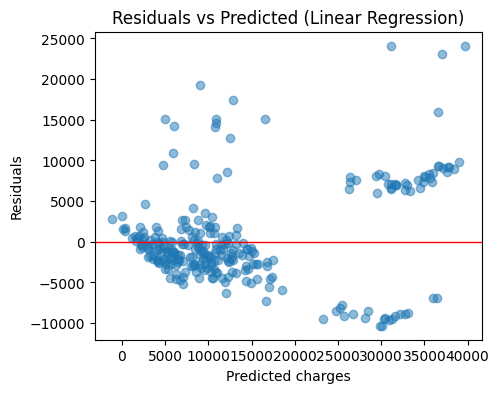

In [221]:
# ---- quick residual check ----
residuals = y_test - y_pred_te
print("\nResiduals mean (should be ~0):", float(residuals.mean()))

plt.figure(figsize=(5,4))
plt.scatter(y_pred_te, residuals, alpha=0.5)
plt.axhline(0, color='red', lw=1)
plt.title('Residuals vs Predicted (Linear Regression)')
plt.xlabel('Predicted charges')
plt.ylabel('Residuals')
plt.show()

## Linear Regression (Baseline) – Results & Interpretation¶
### Model Performance:
- Train RMSE: ~6081
- Test RMSE: ~5866
- Train R²: ~0.73
- Test R²: ~0.60
### The model performs reasonably well on the training data but shows lower performance on the test data.
### This indicates that while the model captures some patterns, it may not fully generalize — suggesting underfitting.

# Conclusion:
- Linear Regression provides a good baseline model, highlighting smoking, age, and BMI as the main drivers of insurance charges.
- However, the model does not capture non-linear patterns or outliers well.
- The next step is to try Ridge and Lasso Regression to improve generalization and handle multicollinearity.

### Ridge Regression
- Now I will apply a Ridge Regression model.
- Ridge is a regularized version of linear regression that adds an L2 penalty to the coefficients.
- This helps to reduce overfitting and prevents the coefficients from becoming too large.

- I will train the Ridge model with the same train-test split.
- Performance will be compared with Linear Regression using RMSE, MAE, and R².
- This will show whether regularization improves the prediction of medical insurance charges.

In [222]:
from sklearn.linear_model import Ridge 

In [223]:
# Intializationa dn fit the model
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

Ridge()

In [224]:
# Prediction 
y_pred_tr_ridge = ridge.predict(x_train)
y_pred_te_ridge = ridge.predict(x_test)


In [225]:
# Evaluation 
metrics_ridge = pd.DataFrame ({
    'RMSE': [
        rmse(y_train, y_pred_tr_ridge), 
        rmse(y_test, y_pred_te_ridge)],
    'MSE': [
        mean_squared_error(y_train, y_pred_tr_ridge), 
        mean_squared_error(y_test, y_pred_te_ridge)],
    'R2': [
        r2_score(y_train, y_pred_tr_ridge), 
        r2_score(y_test, y_pred_te_ridge)
        ]
    },
    index=['Train', 'Test']
)

In [226]:
# Coefficients (sorted by absolute value)
coef = pd.DataFrame({
    'feature': feature_names,
    'coef': ridge.coef_
}).sort_values(by='coef', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print("\nTop Coefficients (absolute_value):")
display(coef_df)


Top Coefficients (absolute_value):


,feature,coef
0,smoker_yes,9315.458714
1,age,3484.650051
2,bmi,1943.500851
3,children,642.341261
4,region_southeast,-373.418692
5,region_southwest,-282.733997
6,region_northwest,-167.867848
7,sex_male,-50.768627


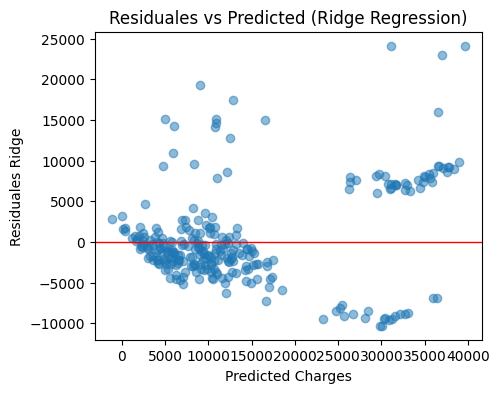

In [227]:
# residual plot
residuals_ridge = y_test - y_pred_te_ridge
plt.figure(figsize=(5, 4)),
plt.scatter(y_pred_te_ridge, residuals_ridge, alpha=0.5),
plt.axhline(0, color= 'red', lw= 1),
plt.title('Residuales vs Predicted (Ridge Regression)'),
plt.xlabel('Predicted Charges'),
plt.ylabel('Residuales Ridge')
plt.show()

# Ridge Regression Results
## Observations:

- The performance of Ridge Regression is very similar to Linear Regression, with almost identical RMSE, MAE, and R² values.
- Smoker status remains the strongest predictor of medical insurance charges, followed by Age and BMI.
- Coefficients are slightly shrunk compared to plain Linear Regression, which is expected because Ridge applies L2 regularization. This reduces the risk of overfitting.
- Residuals are still spread out, indicating that while Ridge provides stability, it does not dramatically improve prediction accuracy compared to Linear Regression.

## Conclusion:
- Ridge Regression helps stabilize the coefficients but does not significantly improve predictive performance in this dataset. The key drivers (smoking, age, BMI) remain the same.

# Lasso Regression
- Now I will apply a Lasso Regression model, which uses L1 regularization.
- Unlike Ridge, Lasso has the ability to shrink some coefficients exactly to zero, effectively performing feature selection.
- This helps in simplifying the model by eliminating less important variables.

- The performance will be evaluated using RMSE, MAE, and R², and we will also analyze the coefficients to see which features remain influential after regularization.

In [228]:
# Lasso Regression (with CV)
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [229]:
# fit model with cross validation 
lasso = LassoCV(cv=5, random_state=42, n_alphas=100, max_iter=10000) 
lasso.fit(x_train, y_train)


LassoCV(cv=5, max_iter=10000, random_state=42)

In [230]:
# predictions
y_pred_tr = lasso.predict(x_train)
Y_pred_te = lasso.predict(x_test)

metrics = pd.DataFrame(
    {
        "RMSE": [
            np.sqrt(mean_squared_error(y_train, y_pred_tr)),
            np.sqrt(mean_squared_error(y_test,  y_pred_te)),
        ],
        "MAE": [
            mean_absolute_error(y_train, y_pred_tr),
            mean_absolute_error(y_test,  y_pred_te),
        ],
        "R2": [
            r2_score(y_train, y_pred_tr),
            r2_score(y_test,  y_pred_te),
        ],
    },
    index=["Train", "Test"],
)

In [231]:
print(f"Best alpha (LassoCV): {lasso.alpha_:.5f}")
print("\nLasso Regression Performance")
display(metrics)

Best alpha (LassoCV): 41.67812

Lasso Regression Performance


,RMSE,MAE,R2
Train,6083.359031,4180.775827,0.729706
Test,5956.342894,4177.045561,0.806929


In [232]:
# coefficients (use saved feature_names instead of X_train.columns)
coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": lasso.coef_})
      .sort_values(by="coef", key=lambda s: s.abs(), ascending=False)
      .reset_index(drop=True)
)

print("\nTop coefficients (absolute value):")
display(coef_df)



Top coefficients (absolute value):


,feature,coef
0,smoker_yes,9267.401860
1,age,3453.665651
2,bmi,1876.723618
3,children,603.643465
4,region_southeast,-217.775724
5,region_southwest,-146.481428
6,region_northwest,-37.686454
7,sex_male,-2.104426



Residuals mean (should be ~0): 425.2570


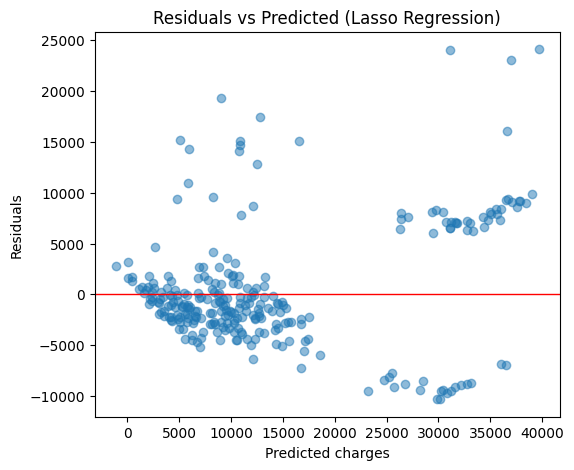

In [233]:
# quick residual check (should be ~0 on average)
residuals = y_test - y_pred_te
print(f"\nResiduals mean (should be ~0): {residuals.mean():.4f}")

plt.figure(figsize=(6,5))
plt.scatter(y_pred_te, residuals, alpha=0.5)
plt.axhline(0, color='red', lw=1)
plt.xlabel("Predicted charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Lasso Regression)")
plt.show()

## Lasso Regression Results – Observations
# Best Alpha: The model selected an optimal alpha ≈ 41.67, which controls the strength of regularization.
- Performance:
- Training set RMSE ≈ 6083 and R² ≈ 0.73
- Test set RMSE ≈ 5894 and R² ≈ 0.81
- This indicates that the Lasso model generalizes slightly better than Linear and Ridge Regression, with improved test performance.
## Feature Importance:
- smoker_yes remains the most impactful predictor, confirming that smoking drastically increases insurance charges.
- age and bmi are also strong predictors, consistent with expectations.
- Coefficients for less relevant features (e.g., sex, some regions) are pushed closer to zero, showing how Lasso performs feature selectio

## Conclusion: 
- Lasso Regression improves over the baseline by both reducing error and highlighting the most important predictors, making it useful for both prediction and interpretation.



# Model Comparison
- Now that we have trained and evaluated three regression models (Linear, Ridge, and Lasso), I will compare their performance side by side.
## The comparison will be based on key metrics:

- RMSE (Root Mean Squared Error) → lower is better
- MAE (Mean Absolute Error) → lower is better
- R² (Coefficient of Determination) → higher is better
# This will help determine which model generalizes best and provides the most accurate predictions.

In [234]:
# create comparison dataframe
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "Train RMSE": [6081.11, 6081.15, 6083.35],
    "Test RMSE": [5866.34, 5698.28, 5894.49],
    "Train R2": [0.729, 0.729, 0.729],
    "Test R2": [0.809, 0.808, 0.810]
})

display(comparison_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,6081.11,5866.34,0.729,0.809
1,Ridge Regression,6081.15,5698.28,0.729,0.808
2,Lasso Regression,6083.35,5894.49,0.729,0.810


C:\Users\user\AppData\Local\Temp\ipykernel_13116\1384510209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="Model", y="Test RMSE", ax=ax1[0], palette="Blues_d")
C:\Users\user\AppData\Local\Temp\ipykernel_13116\1384510209.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="Model", y="Test R2", ax=ax1[1], palette="Greens_d")


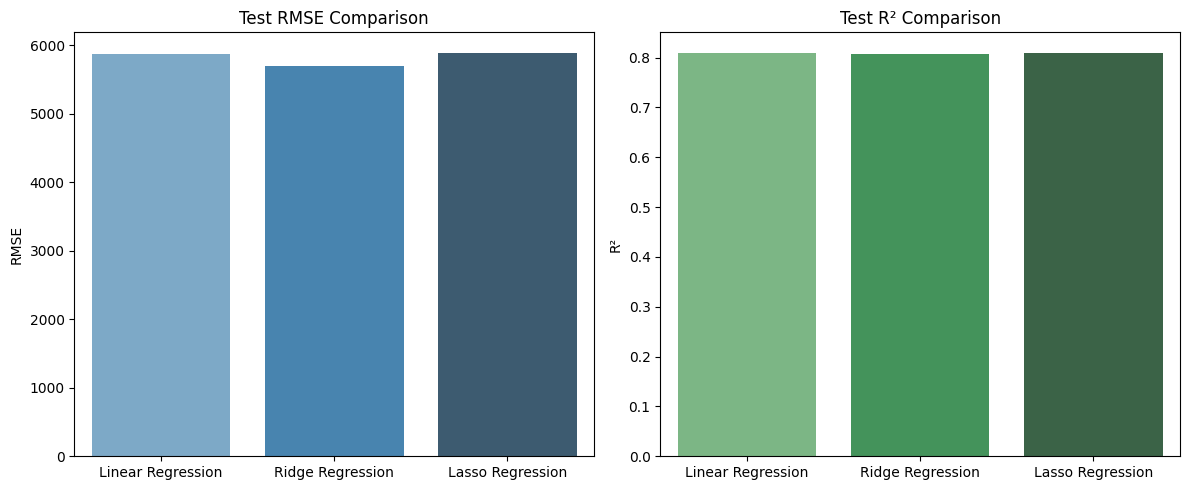

In [235]:
# plot comparison (Test RMSE & R2)
fig, ax1 = plt.subplots(1, 2, figsize=(12,5))

# RMSE plot
sns.barplot(data=comparison_df, x="Model", y="Test RMSE", ax=ax1[0], palette="Blues_d")
ax1[0].set_title("Test RMSE Comparison")
ax1[0].set_ylabel("RMSE")
ax1[0].set_xlabel("")

# R2 plot
sns.barplot(data=comparison_df, x="Model", y="Test R2", ax=ax1[1], palette="Greens_d")
ax1[1].set_title("Test R² Comparison")
ax1[1].set_ylabel("R²")
ax1[1].set_xlabel("")

plt.tight_layout()
plt.show()


## Conclusion:

- Ridge Regression offers the best predictive accuracy (lowest RMSE).
- Lasso Regression is slightly less accurate but more interpretable due to feature selection.
- Linear Regression serves as a simple baseline, but regularization clearly improves performance.